# VedaVision — Compound Leaf Preprocessing (Fixed · Single-Image Experiment)
**Module:** Compound Leaf Analysis  
**Purpose:** Experiment and verify pipeline on ONE image before batch processing  


---
### Pipeline
```
IMAGE_PATH (your file)
   ↓
Cell 2 : Load + display original
   ↓
Cell 3 : Letterbox resize → 512×512 (aspect-ratio preserving)
   ↓
Cell 4 : LAB + ExG dual-mask background removal
   ↓
Cell 5 : Enhancement — Bilateral → CLAHE → Unsharp mask
   ↓
Cell 6 : Shape features  (11 dims — dimensionless ratios + Hu moments)
   ↓
Cell 7 : Colour features (44 dims — channel stats + hue histogram)
   ↓
Cell 8 : Texture features (36 dims — GLCM + LBP)
   ↓
Cell 9 : Vein features   (4 dims  — normalised skeleton ratios)
   ↓
Cell 10: Whole-leaf structural features (5 dims — stable ratios only)
   ↓
Cell 11: Assemble → flat feature vector → display + save CSV
   ↓
Cell 12: Visual summary (all pipeline stages in one figure)
   ↓
Cell 13: Batch processing (entire dataset folder)
```

## Cell 1 — ⚙️ Configuration  ← CHANGE THIS CELL ONLY

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHANGE THESE THREE VALUES — everything else runs automatically
# ═══════════════════════════════════════════════════════════════════════════════

# IMAGE_PATH = '../dataset/raw/nil_awariya.jpg'   # ← path to your image file
# IMAGE_PATH = '../dataset/raw/thunpath_kurundu.jpg'   # ← path to your image file
# IMAGE_PATH = '../dataset/raw/kasthuri_dehi.jpg'   # ← path to your image file
IMAGE_PATH = '../dataset/raw/kattakumanjal.jpg'   # ← path to your image file
# IMAGE_PATH = '../dataset/raw/ranawara.jpg'   # ← path to your image file
# IMAGE_PATH = '../dataset/raw/kathurupila.jpg'   # ← path to your image file
                                    

# SPECIES    = 'nil_awariya'               # ← species name (used in CSV metadata)
# SPECIES    = 'thunpath_kurundu'              
# SPECIES    = 'kasthuri_dehi'              
# SPECIES    = 'kattakumanjal'              
# SPECIES    = 'ranawara'              
SPECIES    = '-------'              

VIEW_SIDE  = 'top'                 

# ══════════════════════════════════════════════════════════════════════════════
# Pipeline parameters — reasoned defaults, no magic numbers
# ═══════════════════════════════════════════════════════════════════════════════
TARGET_LONG   = 512       # Longest side target px. 512 = power-of-two, preserves
                          # vein detail on small Moringa leaflets (224 would under-resolve)

MIN_COMP_FRAC = 0.001     # Min connected component size as fraction of image area
                          # 0.1% of 512² = 262 px² — removes dust/speckle noise

LBP_RADIUS    = 3         # LBP neighbourhood radius in px
LBP_POINTS    = 24        # LBP sample points = 8 × radius (standard relationship)

GLCM_DIST     = [1, 3]   # GLCM distances: 1=immediate neighbours, 3=medium range
                          # Two distances capture both fine and coarse texture structure
GLCM_ANGLES   = [0, 1.5707963, 0.7853981, 2.3561944]  # 0°, 90°, 45°, 135°
                          # Four angles → averaged for rotation invariance

print('Configuration loaded.')
print(f'  Image   : {IMAGE_PATH}')
print(f'  Species : {SPECIES}')
print(f'  View    : {VIEW_SIDE}')


Configuration loaded.
  Image   : ../dataset/raw/kattakumanjal.jpg
  Species : -------
  View    : top


## Cell 2 — Imports

In [5]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.morphology import skeletonize

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 9

def show(pairs, cols=4, suptitle=None):
    """Display list of (image, title) tuples in a grid."""
    n    = len(pairs)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).flatten()
    for ax, (img, title) in zip(axes, pairs):
        if img.ndim == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Imports OK')


Imports OK


## Cell 3 — Load Image

Loaded : ../dataset/raw/kattakumanjal.jpg
Shape  : (4032, 3024, 3)  (H × W × C)
dtype  : uint8
AR     : 0.750  (w/h)


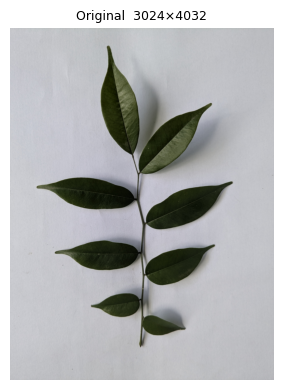

In [6]:
import os

assert os.path.exists(IMAGE_PATH), (
    f'Image not found: {IMAGE_PATH}\n'
    f'Check IMAGE_PATH in Cell 1.'
)

img_orig = cv2.imread(IMAGE_PATH)
assert img_orig is not None, f'cv2.imread failed on: {IMAGE_PATH}'

print(f'Loaded : {IMAGE_PATH}')
print(f'Shape  : {img_orig.shape}  (H × W × C)')
print(f'dtype  : {img_orig.dtype}')
print(f'AR     : {img_orig.shape[1] / img_orig.shape[0]:.3f}  (w/h)')

show([(img_orig, f'Original  {img_orig.shape[1]}×{img_orig.shape[0]}')], cols=1)


## Cell 4 — Letterbox Resize (Aspect-Ratio Preserving)

**Why letterbox and NOT naive `resize(512,512)`?**  
A tall Moringa leaf (AR≈0.25) naively resized becomes squashed — your `aspect_ratio` 
feature would then measure the distortion you introduced, not the leaf's true shape.  
Letterbox = scale longest side to 512px, pad the short side with white.

**Why white padding?**  
Matches dataset background → background removal sees uniform white border → correct mask seeding.

Original  : 3024w × 4032h  AR=0.750
Scaled to : 384w × 512h  (scale=0.1270)
Padded to : 512w × 512h
AR before : 0.7500
AR after  : 0.7500  ← must match above
Pad top=0px  left=64px


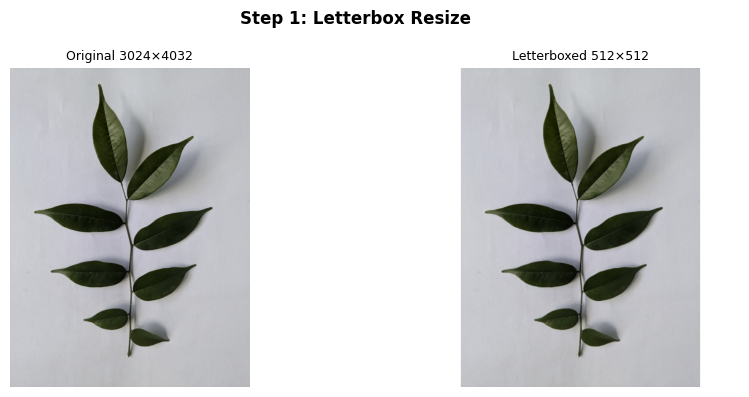

In [7]:
def letterbox_resize(img, target_long=512, pad_colour=(255, 255, 255)):
    """
    Scale longest side to target_long, pad short side to make square.
    Returns (padded_img, meta_dict).
    pad_colour = white: matches dataset background so mask seeding is unaffected.
    INTER_AREA for downscale: averages source pixels → no aliasing on vein patterns.
    INTER_LINEAR for upscale: smooth, no ringing.
    """
    h, w   = img.shape[:2]
    scale  = target_long / max(h, w)
    new_w  = int(round(w * scale))
    new_h  = int(round(h * scale))
    interp = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_LINEAR
    scaled = cv2.resize(img, (new_w, new_h), interpolation=interp)

    pad_h      = target_long - new_h
    pad_w      = target_long - new_w
    pad_top    = pad_h // 2;  pad_bottom = pad_h - pad_top
    pad_left   = pad_w // 2;  pad_right  = pad_w - pad_left

    padded = cv2.copyMakeBorder(scaled, pad_top, pad_bottom, pad_left, pad_right,
                                 cv2.BORDER_CONSTANT, value=pad_colour)
    meta = dict(scale=scale, pad_top=pad_top, pad_left=pad_left,
                orig_h=h, orig_w=w, new_h=new_h, new_w=new_w)
    return padded, meta


img_resized, resize_meta = letterbox_resize(img_orig, TARGET_LONG)

print(f'Original  : {img_orig.shape[1]}w × {img_orig.shape[0]}h  AR={img_orig.shape[1]/img_orig.shape[0]:.3f}')
print(f'Scaled to : {resize_meta["new_w"]}w × {resize_meta["new_h"]}h  (scale={resize_meta["scale"]:.4f})')
print(f'Padded to : {img_resized.shape[1]}w × {img_resized.shape[0]}h')
print(f'AR before : {resize_meta["orig_w"]/resize_meta["orig_h"]:.4f}')
print(f'AR after  : {resize_meta["new_w"]/resize_meta["new_h"]:.4f}  ← must match above')
print(f'Pad top={resize_meta["pad_top"]}px  left={resize_meta["pad_left"]}px')

show([
    (img_orig,    f'Original {img_orig.shape[1]}×{img_orig.shape[0]}'),
    (img_resized, f'Letterboxed {TARGET_LONG}×{TARGET_LONG}'),
], cols=2, suptitle='Step 1: Letterbox Resize')


## Cell 5 — Background Removal 

─────────────────────────────────────────────────────────────────
  v5.1 | Mask: loose  | Seed: 8.2% (normal)
  Pipeline : seed 8.2% → cand 10.9% → grown 10.9% → leaflet 11.2%
  Rachis   : 10963 px (4.182%)
  Final    : 11.3% coverage | 1 components
─────────────────────────────────────────────────────────────────
✓  Coverage within expected range.


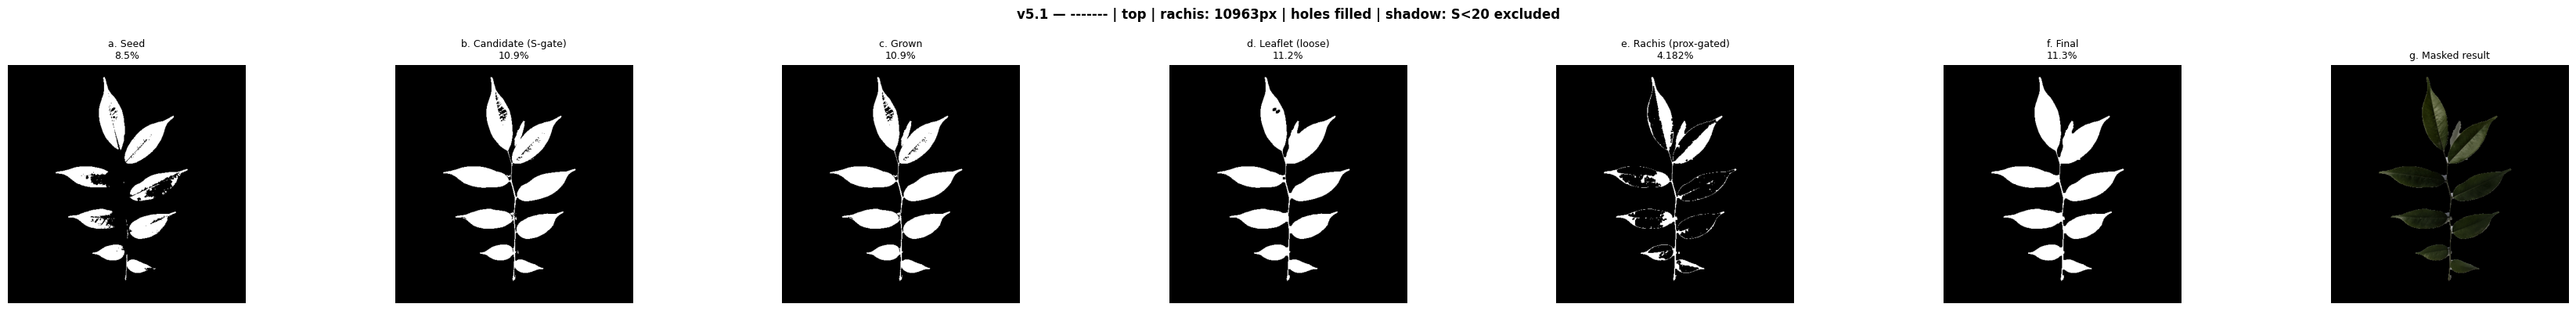

In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Background Removal v5.1  (Final Combined)                        ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  What each version got right:                                               ║
# ║    v4.1 : shadow removal via L+a veto (works well for shadows)              ║
# ║    v5.0 : S-gate for shadow (better), rachis candidate via b-channel        ║
# ║                                                                             ║
# ║  What was still broken in v5.0:                                             ║
# ║    1. MORPH_OPEN inside _build_rachis_mask kills thin rachis lines          ║
# ║       (a 3×3 open erodes any line thinner than 3px → gone)                 ║
# ║    2. Rachis candidate had shadow blobs (b-channel catches dark shadows too)║
# ║    3. Over-closing (k3 iter=2) merging pinnate leaflets into blobs          ║
# ║    4. Hole fill (_fill_holes) was present but applied AFTER _remove_noise   ║
# ║       which already deleted the thin rachis as isolated noise               ║
# ║                                                                             ║
# ║  v5.1 fixes:                                                                ║
# ║    A. Rachis: NO morph_open (use dilation proximity only, keep thin lines)  ║
# ║    B. Rachis shadow guard: add S > 35 AND L < 150 to b-channel gate        ║
# ║       (shadows have low S; paper has high L → both fail the gate)          ║
# ║    C. Closing: back to k3 iter=1 (tight) / k5 iter=1 (loose) — not iter=2 ║
# ║    D. Hole fill BEFORE _remove_noise on the union mask so filled leaflets  ║
# ║       don't lose their interior pixels as "noise"                           ║
# ║    E. Rachis _remove_noise skipped — thin lines are valid, not noise        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import cv2
import numpy as np


# ══════════════════════════════════════════════════════════════════════════════
# UTILITIES
# ══════════════════════════════════════════════════════════════════════════════

def _remove_noise(mask, min_frac=0.001, img_area=512 * 512):
    """Remove connected components smaller than min_frac × image area."""
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    clean = np.zeros_like(mask)
    min_px = int(img_area * min_frac)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_px:
            clean[labels == i] = 255
    return clean


def _fill_holes(mask):
    """
    Fill enclosed holes inside leaflets using border flood-fill on inverted mask.
    Inter-leaflet gaps touch the image border → NOT filled (safe for compound leaves).
    Internal holes (light-bleed, translucent spots) → filled.
    """
    h, w   = mask.shape
    inv    = cv2.bitwise_not(mask)
    flood  = inv.copy()
    ffmask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, ffmask, (0, 0), 0)
    return cv2.bitwise_or(mask, flood)


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 1 — SEED  (high-confidence green tissue)
# ══════════════════════════════════════════════════════════════════════════════

def _build_seed(img_resized, img_lab_float, hsv, is_padding, k3,
                min_comp_frac, img_area):
    """
    Two-tier green seed:
      Tier 1 (normal):  ExG>20, S>25, L<130  — clear green leaflets
      Tier 2 (relaxed): ExG>8,  S>15, L<150  — dark-species fallback
    """
    img_f = img_resized.astype(np.float32)
    exg   = 2.0 * img_f[:, :, 1] - img_f[:, :, 2] - img_f[:, :, 0]
    s_ch  = hsv[:, :, 1].astype(np.float32)
    L_ch  = img_lab_float[:, :, 0]

    seed = ((exg > 20) & (s_ch > 25) & (L_ch < 130)).astype(np.uint8) * 255
    seed[is_padding] = 0
    seed = cv2.morphologyEx(seed, cv2.MORPH_OPEN, k3, iterations=1)
    seed = _remove_noise(seed, min_frac=min_comp_frac, img_area=img_area)

    cov     = float((seed > 0).sum()) / img_area * 100.0
    relaxed = False

    if cov < 1.0:
        seed = ((exg > 8) & (s_ch > 15) & (L_ch < 150)).astype(np.uint8) * 255
        seed[is_padding] = 0
        seed = cv2.morphologyEx(seed, cv2.MORPH_OPEN, k3, iterations=1)
        seed = _remove_noise(seed, min_frac=min_comp_frac, img_area=img_area)
        cov     = float((seed > 0).sum()) / img_area * 100.0
        relaxed = True

    return seed, cov, relaxed


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 2 — COLOUR MODEL  (learned per-image from seed)
# ══════════════════════════════════════════════════════════════════════════════

def _learn_colour_model(img_lab_float, seed_mask):
    px = img_lab_float[seed_mask > 0]
    if len(px) < 50:
        return np.array([100.0, 115.0, 130.0]), np.array([20.0, 10.0, 10.0])
    return px.mean(axis=0), np.maximum(px.std(axis=0), 8.0)


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — CANDIDATE MAP  (S-gated shadow exclusion)
# ══════════════════════════════════════════════════════════════════════════════

def _build_candidate(img_lab_float, hsv, mean_lab, std_lab, sigma_thresh=2.5):
    """
    Pixels must pass BOTH:
      (a) within sigma_thresh of the learned leaf LAB model
      (b) S > 20  — has real colour (not an achromatic paper shadow)

    Why S-gate beats L+a veto (from v4.x):
      Paper shadow : achromatic darkening → S ≈ 0-20  → EXCLUDED  ✓
      Rachis tissue: real brown/tan colour → S ≈ 30-100 → INCLUDED ✓
      Leaflet tissue: green               → S ≈ 40-150 → INCLUDED ✓
    The L+a veto was vetoing rachis because rachis and shadow overlap in L and a.
    S separates them cleanly.
    """
    diff       = np.abs(img_lab_float - mean_lab)
    z          = diff / std_lab
    sigma_gate = z.max(axis=2) < sigma_thresh
    s_ch       = hsv[:, :, 1].astype(np.float32)
    is_shadow  = s_ch < 20
    return (sigma_gate & ~is_shadow).astype(np.uint8) * 255


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 4 — REGION GROW
# ══════════════════════════════════════════════════════════════════════════════

def _grow_seed(seed, candidate, n_iter=40, ks=5):
    k = np.ones((ks, ks), np.uint8)
    grown = seed.copy()
    prev  = -1
    for _ in range(n_iter):
        dilated = cv2.dilate(grown, k, iterations=1)
        grown   = cv2.bitwise_and(dilated, candidate)
        curr    = int(grown.sum())
        if curr == prev:
            break
        prev = curr
    return grown


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 5 — STRUCTURE SELECTION  (tight/loose)
# ══════════════════════════════════════════════════════════════════════════════

def _select_structure(grown, min_comp_frac, img_area):
    """
    k3 iter=1 (tight): preserves inter-leaflet gaps in pinnate leaves.
    k5 iter=1 (loose): merges close regions for trifoliate/sparse leaves.
    Choice based on component count in tight mask.

    NOTE: deliberately back to iter=1 (v5.0 used iter=2 which merged pinnate
    leaflets into blobs — visible in image 2 panel e).
    """
    k3 = np.ones((3, 3), np.uint8)
    k5 = np.ones((5, 5), np.uint8)

    m_tight = cv2.morphologyEx(grown, cv2.MORPH_CLOSE, k3, iterations=1)
    m_tight = _remove_noise(m_tight, min_frac=min_comp_frac, img_area=img_area)

    m_loose = cv2.morphologyEx(grown, cv2.MORPH_CLOSE, k5, iterations=1)
    m_loose = _remove_noise(m_loose, min_frac=min_comp_frac, img_area=img_area)

    n_tight    = cv2.connectedComponentsWithStats(m_tight)[0] - 1
    tight_area = int((m_tight > 0).sum())
    loose_area = int((m_loose > 0).sum())

    use_tight = (n_tight >= 3) and (tight_area >= loose_area * 0.25)
    return (m_tight if use_tight else m_loose,
            "tight" if use_tight else "loose",
            n_tight, tight_area, loose_area)


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 6 — RACHIS MASK  (proximity-gated, NO morph_open)
# ══════════════════════════════════════════════════════════════════════════════

def _build_rachis_mask(img_resized, img_lab_float, hsv, leaflet_mask,
                       is_padding, proximity_px=15):
    """
    Detect rachis (woody stem) and petiole pixels.

    Rachis colour profile:
      b channel > 133   → yellow/brown shift (woody tissue)
      S > 35            → real colour, NOT achromatic shadow  ← KEY FIX
      L > 50, L < 150   → not black shadow, not white paper

    Dark-green rachis variant (some species):
      ExG in (3, 18)    → slightly green but not as green as leaflets
      S > 20, L < 140

    CRITICAL FIX vs v5.0:
      NO MORPH_OPEN on the rachis mask.
      A 3×3 open erodes any structure thinner than 3px → kills the rachis line.
      Instead: proximity gate alone filters spurious detections.
      The proximity gate (leaflet_dilated AND rachis_candidate) is sufficient
      because background noise is spatially separated from the leaf.

    Shadow guard added to b-channel gate:
      Old:  b>133, S>30, L>50, L<155
      New:  b>133, S>35, L>50, L<150
      Raising S>35 excludes dark paper shadows that have slight colour cast.
      Lowering L<150 excludes bright regions that were leaking.

    Proximity: only rachis pixels within proximity_px of detected leaflets.
    No _remove_noise on rachis — thin lines are valid, not noise.
    """
    if (leaflet_mask > 0).sum() < 200:
        return np.zeros_like(leaflet_mask)

    img_f = img_resized.astype(np.float32)
    exg   = 2.0 * img_f[:, :, 1] - img_f[:, :, 2] - img_f[:, :, 0]
    b_ch  = img_lab_float[:, :, 2]
    s_ch  = hsv[:, :, 1].astype(np.float32)
    L_ch  = img_lab_float[:, :, 0]

    # Brown/tan rachis (majority of species)
    rachis_brown = (
        (b_ch > 133) & (s_ch > 35) & (L_ch > 50) & (L_ch < 150)
    ).astype(np.uint8) * 255

    # Dark-green rachis (minority of species with green stems)
    rachis_green = (
        (exg > 3) & (exg < 18) & (s_ch > 20) & (L_ch < 140)
    ).astype(np.uint8) * 255

    rachis_candidate = cv2.bitwise_or(rachis_brown, rachis_green)
    rachis_candidate[is_padding] = 0

    # Proximity gate: only keep rachis adjacent to leaflets
    # NO MORPH_OPEN — thin lines must survive
    k_prox   = np.ones((proximity_px * 2 + 1, proximity_px * 2 + 1), np.uint8)
    expanded = cv2.dilate(leaflet_mask, k_prox, iterations=1)
    rachis   = cv2.bitwise_and(rachis_candidate, expanded)

    # One small close (NOT open) to connect broken rachis segments
    # Close bridges gaps, never erodes → safe for thin lines
    k3     = np.ones((3, 3), np.uint8)
    rachis = cv2.morphologyEx(rachis, cv2.MORPH_CLOSE, k3, iterations=1)

    return rachis


# ══════════════════════════════════════════════════════════════════════════════
# MAIN FUNCTION v5.1
# ══════════════════════════════════════════════════════════════════════════════

def select_mask_v5_1(img_resized, min_comp_frac=0.001, sigma_thresh=2.5):
    """
    Background removal v5.1 — Combined Best-of Pipeline.

    Stages:
      1  Build green-tissue seed (two-tier ExG+S+L)
      2  Learn per-image LAB colour model from seed
      3  Build candidate map (sigma gate + S>20 shadow exclusion)
      4  Region grow seed → candidate
      5  Tight/loose structure selection (iter=1, NOT iter=2)
      6  Build rachis mask (b-channel+S gate, proximity-gated, NO open)
      7  Union leaflet mask + rachis mask
      8  Flood-fill holes in leaflets (BEFORE final _remove_noise)
      9  Final light close + clean

    Returns: mask_final, mask_choice, diag
    """
    img_area      = img_resized.shape[0] * img_resized.shape[1]
    img_lab_u8    = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
    img_lab_float = img_lab_u8.astype(np.float32)
    hsv           = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    is_padding    = np.all(img_resized >= 252, axis=2)
    k3            = np.ones((3, 3), np.uint8)

    # 1. Seed
    seed, seed_cov, seed_relaxed = _build_seed(
        img_resized, img_lab_float, hsv, is_padding, k3, min_comp_frac, img_area)

    # 2. Colour model
    mean_lab, std_lab = _learn_colour_model(img_lab_float, seed)

    # 3. Candidate map
    candidate = _build_candidate(img_lab_float, hsv, mean_lab, std_lab, sigma_thresh)
    candidate[is_padding] = 0

    # 4. Region grow
    grown = _grow_seed(seed, candidate)
    grown = _remove_noise(grown, min_frac=min_comp_frac, img_area=img_area)

    # 5. Structure selection
    leaflet_mask, mask_choice, n_tight, tight_area, loose_area = _select_structure(
        grown, min_comp_frac, img_area)

    # 6. Rachis mask (NO open, NO remove_noise)
    rachis_mask = _build_rachis_mask(
        img_resized, img_lab_float, hsv, leaflet_mask, is_padding, proximity_px=15)
    rachis_px   = int((rachis_mask > 0).sum())

    # 7. Union
    combined = cv2.bitwise_or(leaflet_mask, rachis_mask)

    # 8. Hole fill BEFORE remove_noise
    #    Order matters: fill first so filled interiors aren't deleted as noise
    filled = _fill_holes(combined)

    # 9. Final clean
    mask_final = cv2.morphologyEx(filled, cv2.MORPH_CLOSE, k3, iterations=1)
    mask_final = _remove_noise(mask_final, min_frac=min_comp_frac, img_area=img_area)
    # Re-apply padding exclusion in case any border artifact slipped through
    mask_final[is_padding] = 0

    coverage     = (mask_final > 0).sum() / mask_final.size * 100
    n_components = cv2.connectedComponentsWithStats(mask_final)[0] - 1

    diag = {
        "seed_coverage_pct":    round(seed_cov, 2),
        "seed_relaxed":         seed_relaxed,
        "leaf_mean_LAB":        mean_lab.round(1).tolist(),
        "leaf_std_LAB":         std_lab.round(1).tolist(),
        "sigma_thresh":         sigma_thresh,
        "candidate_pct":        round(float((candidate > 0).sum()) / img_area * 100, 2),
        "grown_pct":            round(float((grown > 0).sum()) / img_area * 100, 2),
        "leaflet_pct":          round(float((leaflet_mask > 0).sum()) / img_area * 100, 2),
        "rachis_px":            rachis_px,
        "rachis_pct":           round(rachis_px / img_area * 100, 3),
        "n_tight_components":   n_tight,
        "tight_area_px":        tight_area,
        "loose_area_px":        loose_area,
        "mask_choice":          mask_choice,
        "final_coverage_pct":   round(coverage, 2),
        "n_final_components":   n_components,
    }

    return mask_final, mask_choice, diag


# ══════════════════════════════════════════════════════════════════════════════
# RUN
# ══════════════════════════════════════════════════════════════════════════════

mask_final, mask_choice, _diag = select_mask_v5_1(
    img_resized, min_comp_frac=MIN_COMP_FRAC)
img_masked   = cv2.bitwise_and(img_resized, img_resized, mask=mask_final)
coverage     = _diag["final_coverage_pct"]
n_components = _diag["n_final_components"]

print("─" * 65)
print(f"  v5.1 | Mask: {_diag['mask_choice']}  | "
      f"Seed: {_diag['seed_coverage_pct']:.1f}% "
      f"({'relaxed' if _diag['seed_relaxed'] else 'normal'})")
print(f"  Pipeline : seed {_diag['seed_coverage_pct']:.1f}%"
      f" → cand {_diag['candidate_pct']:.1f}%"
      f" → grown {_diag['grown_pct']:.1f}%"
      f" → leaflet {_diag['leaflet_pct']:.1f}%")
print(f"  Rachis   : {_diag['rachis_px']} px ({_diag['rachis_pct']:.3f}%)")
print(f"  Final    : {coverage:.1f}% coverage | {n_components} components")
print("─" * 65)

if coverage < 2.0:
    print("⚠  WARNING: Coverage < 2% — leaf not detected.")
elif coverage > 75.0:
    print("⚠  WARNING: Coverage > 75% — possible background leak.")
else:
    print("✓  Coverage within expected range.")


# ══════════════════════════════════════════════════════════════════════════════
# VISUALISE — 7 panels showing every stage
# ══════════════════════════════════════════════════════════════════════════════

_img_f   = img_resized.astype(np.float32)
_exg_d   = 2.0 * _img_f[:,:,1] - _img_f[:,:,2] - _img_f[:,:,0]
_hsv_d   = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
_lab_d   = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB).astype(np.float32)
_s_d     = _hsv_d[:,:,1].astype(np.float32)
_L_d     = _lab_d[:,:,0]
_b_d     = _lab_d[:,:,2]
_is_pad  = np.all(img_resized >= 252, axis=2)
_k3      = np.ones((3,3), np.uint8)

# Seed
_seed_d = ((_exg_d > 20) & (_s_d > 25) & (_L_d < 130) & ~_is_pad).astype(np.uint8)*255
if (_seed_d > 0).sum() < int(0.01 * img_resized.size / 3):
    _seed_d = ((_exg_d > 8) & (_s_d > 15) & (_L_d < 150) & ~_is_pad).astype(np.uint8)*255

# Candidate
_mean_d, _std_d = _learn_colour_model(_lab_d, _seed_d)
_cand_d = _build_candidate(_lab_d, _hsv_d, _mean_d, _std_d, 2.5)
_cand_d[_is_pad] = 0

# Grown
_grown_d = _grow_seed(_seed_d, _cand_d)
_grown_d = _remove_noise(_grown_d)

# Leaflet mask (structure selection result)
_leaflet_d, _choice_d, _, _, _ = _select_structure(
    _grown_d, MIN_COMP_FRAC, img_resized.shape[0]*img_resized.shape[1])

# Rachis candidate (before proximity gate — for debugging)
_rachis_brown_d = ((_b_d > 133) & (_s_d > 35) & (_L_d > 50) & (_L_d < 150)
                   ).astype(np.uint8) * 255
_rachis_green_d = ((_exg_d > 3) & (_exg_d < 18) & (_s_d > 20) & (_L_d < 140)
                   ).astype(np.uint8) * 255
_rachis_cand_d  = cv2.bitwise_or(_rachis_brown_d, _rachis_green_d)
_rachis_cand_d[_is_pad] = 0

# Rachis after proximity gate
_k_prox   = np.ones((31, 31), np.uint8)   # 15px proximity
_expanded = cv2.dilate(_leaflet_d, _k_prox, iterations=1)
_rachis_d = cv2.bitwise_and(_rachis_cand_d, _expanded)
_rachis_d = cv2.morphologyEx(_rachis_d, cv2.MORPH_CLOSE, _k3, iterations=1)

show([
    (_seed_d,        f"a. Seed\n{(_seed_d>0).mean()*100:.1f}%"),
    (_cand_d,        f"b. Candidate (S-gate)\n{(_cand_d>0).mean()*100:.1f}%"),
    (_grown_d,       f"c. Grown\n{(_grown_d>0).mean()*100:.1f}%"),
    (_leaflet_d,     f"d. Leaflet ({_choice_d})\n{(_leaflet_d>0).mean()*100:.1f}%"),
    (_rachis_d,      f"e. Rachis (prox-gated)\n{(_rachis_d>0).mean()*100:.3f}%"),
    (mask_final,     f"f. Final\n{coverage:.1f}%"),
    (img_masked,     f"g. Masked result"),
], cols=7,
   suptitle=f"v5.1 — {SPECIES} | {VIEW_SIDE} | "
            f"rachis: {_diag['rachis_px']}px | holes filled | "
            f"shadow: S<20 excluded")

## Cell 6 — Enhancement (Bilateral → CLAHE → Unsharp Mask)
Applied only inside the leaf mask. Used for texture and vein extraction — NOT for segmentation.

- **Bilateral filter** (d=9, σ=75): smooths within-leaflet noise, preserves vein edges  
- **CLAHE** (clip=2.5, tile=8×8 on L channel): locally boosts contrast for vein visibility without distorting colour  
- **Unsharp mask** (σ=3, strength=1.5×): sharpens vein boundaries for skeleton extraction

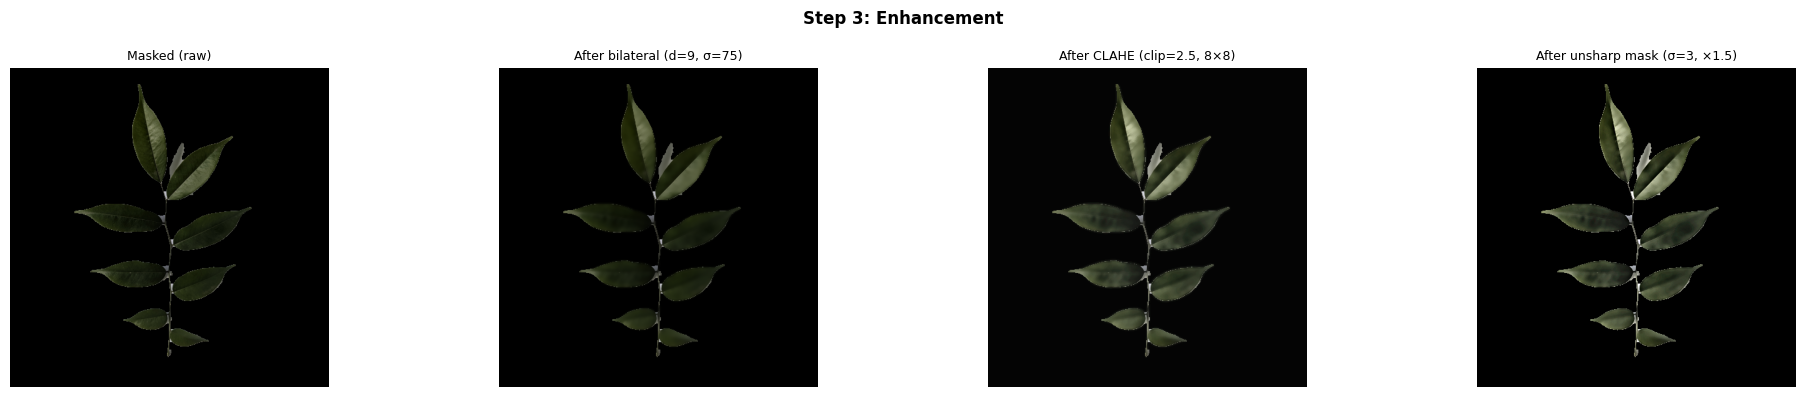

In [9]:
# ── Bilateral filter ─────────────────────────────────────────────────────────
# d=9: 9px neighbourhood diameter — OpenCV recommended for real-time use
# sigmaColor=75: ~30% of 255 range; bridges camera noise (~10 units) but
#   keeps vein-lamina boundary (~40 units) intact
# sigmaSpace=75: spatial influence radius matches sigmaColor for balance
img_bilateral = cv2.bilateralFilter(img_masked, d=9, sigmaColor=75, sigmaSpace=75)

# ── CLAHE on L channel only ───────────────────────────────────────────────────
# Operating in LAB: L=lightness, a/b=colour. Enhancing L boosts contrast
# without shifting the green hue — critical if colour features follow.
# clipLimit=2.5: mid-range clip; 1.0=no enhancement, 4.0=amplifies noise
# tileGridSize=(8,8): 512/8=64px tiles — spatially adaptive, not global
lab_e       = cv2.cvtColor(img_bilateral, cv2.COLOR_BGR2LAB)
l, a_e, b_e = cv2.split(lab_e)
clahe       = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
l_clahe     = clahe.apply(l)
img_clahe   = cv2.cvtColor(cv2.merge([l_clahe, a_e, b_e]), cv2.COLOR_LAB2BGR)

# ── Unsharp mask ──────────────────────────────────────────────────────────────
# GaussianBlur σ=3 captures structures up to ~9px wide (3σ rule)
# addWeighted: sharp = 1.5×original − 0.5×blurred = original + 0.5×(orig−blur)
# Strength 1.5 chosen to reveal secondary veins without amplifying JPEG artefacts
blur      = cv2.GaussianBlur(img_clahe, (0, 0), sigmaX=3)
img_sharp = cv2.addWeighted(img_clahe, 1.5, blur, -0.5, 0)
img_sharp = cv2.bitwise_and(img_sharp, img_sharp, mask=mask_final)  # re-apply mask

show([
    (img_masked,    'Masked (raw)'),
    (img_bilateral, 'After bilateral (d=9, σ=75)'),
    (img_clahe,     'After CLAHE (clip=2.5, 8×8)'),
    (img_sharp,     'After unsharp mask (σ=3, ×1.5)'),
], cols=4, suptitle='Step 3: Enhancement')


## Cell 7 — Shape Features (Whole-Leaf Mask)
**Fix 1 applied:** `area_px`, `perimeter_px`, `eq_diameter_px`, `bbox_w`, `bbox_h` removed — all scale-dependent raw pixel counts.  
**Fix 2 applied:** `ellipse_angle` removed — measures how leaf was placed on table, not species morphology.  
All remaining features are **dimensionless ratios** or **log-transformed moments** — invariant to image scale.

Shape features: 13 dims

  aspect_ratio      :   0.650685
  circularity       :   0.048109
  convexity         :   0.348482
  solidity          :   0.348482
  compactness       :   0.228383
  elongation        :   1.533959
  hu_1              :   0.356790
  hu_2              :   1.279102
  hu_3              :   3.408826
  hu_4              :   3.639057
  hu_5              :   7.401233
  hu_6              :  -6.099750
  hu_7              :  -7.249888


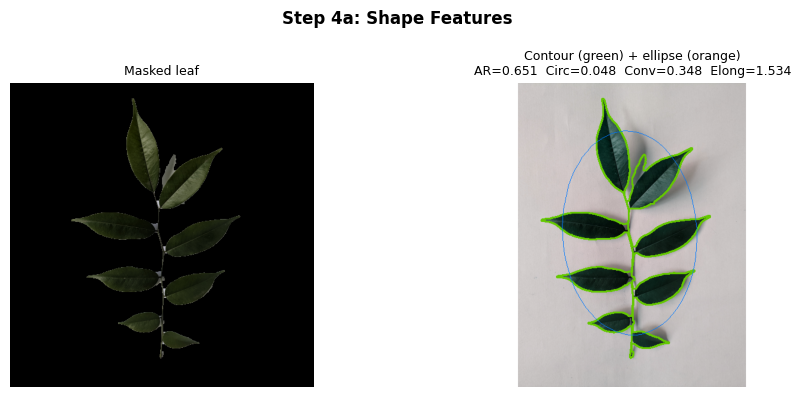

In [10]:
def extract_shape_features(leaf_mask):
    """
    Shape descriptors from whole-leaf binary mask.
    All dimensionless — a leaf at any zoom gives the same values.

    REMOVED (Fix 1 — scale-dependent):
        area_px, perimeter_px, eq_diameter_px, bbox_w, bbox_h
    REMOVED (Fix 2 — pose-dependent):
        ellipse_angle  (the angle a leaf is placed on the table ≠ species trait)

    KEPT:
        aspect_ratio   w/h of bounding box        — elongation
        circularity    4π·A/P²                    — circle=1, needle→0
        convexity      A/hull_A                   — margin smoothness
        solidity       alias of convexity          — standard botany term
        compactness    A/bbox_A                   — rectangular fill
        elongation     minor/major ellipse axis   — pose-invariant elongation
        hu_1..hu_7     log-Hu moments             — rotation+scale+translation invariant
    """
    cnts, _ = cv2.findContours(leaf_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return {}
    cnt = max(cnts, key=cv2.contourArea)

    area      = float(cv2.contourArea(cnt))
    perimeter = float(cv2.arcLength(cnt, closed=True))
    x, y, w, h = cv2.boundingRect(cnt)

    aspect_ratio = float(w) / h if h > 0 else 0.0
    compactness  = area / (w * h) if (w * h) > 0 else 0.0
    circularity  = (4 * np.pi * area / perimeter ** 2) if perimeter > 0 else 0.0
    hull         = cv2.convexHull(cnt)
    hull_area    = float(cv2.contourArea(hull))
    convexity    = area / hull_area if hull_area > 0 else 0.0
    solidity     = convexity

    # Elongation from fitted ellipse — minor/major axis ratio only (angle discarded, Fix 2)
    if len(cnt) >= 5:
        (_, _), (ma, mi), _ = cv2.fitEllipse(cnt)
        elongation = mi / ma if ma > 0 else 0.0
    else:
        elongation = 0.0

    # Hu moments: 7 values, rotation+scale+translation invariant
    M      = cv2.moments(cnt)
    hu     = cv2.HuMoments(M).flatten()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    feats = {
        'aspect_ratio': aspect_ratio,
        'circularity' : circularity,
        'convexity'   : convexity,
        'solidity'    : solidity,
        'compactness' : compactness,
        'elongation'  : elongation,
        # area_px, perimeter_px, eq_diameter_px, bbox_w, bbox_h → REMOVED Fix 1
        # ellipse_angle → REMOVED Fix 2
    }
    for i, val in enumerate(hu_log):
        feats[f'hu_{i+1}'] = float(val)
    return feats


shape_feats = extract_shape_features(mask_final)

print(f'Shape features: {len(shape_feats)} dims')
print()
for k, v in shape_feats.items():
    print(f'  {k:<18s}: {v:>10.6f}')

# Visualise contour + ellipse fit
shape_vis = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB).copy()
cnts_v, _ = cv2.findContours(mask_final, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(shape_vis, cnts_v, -1, (0, 200, 100), 2)
if cnts_v:
    cnt_v = max(cnts_v, key=cv2.contourArea)
    if len(cnt_v) >= 5:
        cv2.ellipse(shape_vis, cv2.fitEllipse(cnt_v), (255, 120, 0), 1)

show([
    (img_masked,  'Masked leaf'),
    (shape_vis,   f'Contour (green) + ellipse (orange)\n'
                   f'AR={shape_feats["aspect_ratio"]:.3f}  '
                   f'Circ={shape_feats["circularity"]:.3f}  '
                   f'Conv={shape_feats["convexity"]:.3f}  '
                   f'Elong={shape_feats["elongation"]:.3f}'),
], cols=2, suptitle='Step 4a: Shape Features')


## Cell 8 — Colour Features (Whole-Leaf Mask)
Channel statistics (mean + std) in BGR, HSV, LAB + Excess Green + normalised hue histogram. All are inherently scale-independent — they are pixel intensity statistics, not pixel counts.

Colour features: 38 dims

  Feature                  Value
  ------------------------------
  bgr_g_mean          :   48.294
  hsv_h_mean          :   39.869
  hsv_s_mean          :  132.365
  hsv_v_mean          :   48.352
  lab_l_mean          :   47.022
  lab_a_mean          :  120.948
  lab_b_mean          :  139.928
  exg_mean            :   27.629


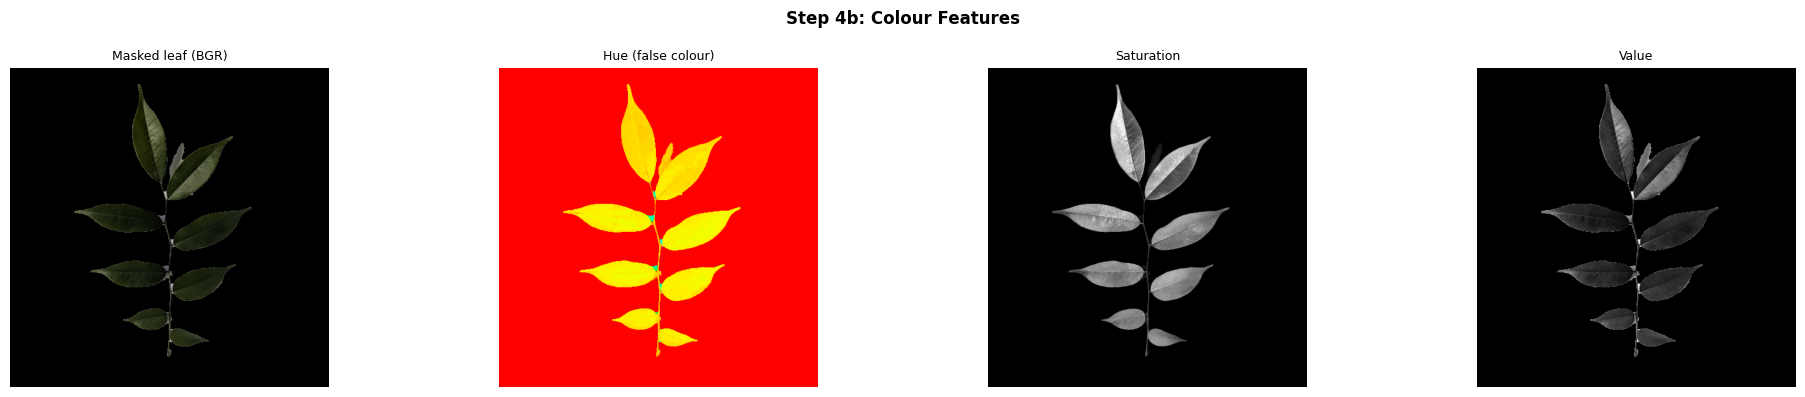

In [11]:
def extract_colour_features(img_bgr, leaf_mask):
    """
    Colour statistics from masked leaf pixels.
    BGR, HSV, LAB channel mean+std + ExG + normalised hue histogram (18 bins).
    All scale-independent: these are per-pixel intensity statistics.
    """
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    img_f   = img_bgr.astype(np.float32)
    exg     = 2 * img_f[:,:,1] - img_f[:,:,2] - img_f[:,:,0]
    px      = leaf_mask > 0
    feats   = {}

    def _stats(arr, prefix):
        vals = arr[px]
        feats[f'{prefix}_mean'] = float(np.mean(vals)) if len(vals) else 0.0
        feats[f'{prefix}_std']  = float(np.std(vals))  if len(vals) else 0.0

    for i, n in enumerate(['b', 'g', 'r']):
        _stats(img_bgr[:,:,i], f'bgr_{n}')
    for i, n in enumerate(['h', 's', 'v']):
        _stats(img_hsv[:,:,i], f'hsv_{n}')
    for i, n in enumerate(['l', 'a', 'b']):
        _stats(img_lab[:,:,i], f'lab_{n}')
    _stats(exg, 'exg')

    # Hue histogram — 18 bins × 20°/bin = 0°–180° (OpenCV scale)
    # Normalised: counts/total → sums to 1.0 → scale invariant
    h_vals = img_hsv[:,:,0][px].astype(np.float32)
    if len(h_vals) > 0:
        hist, _ = np.histogram(h_vals, bins=18, range=(0, 180))
        hist    = hist / (hist.sum() + 1e-6)
        for bi, bv in enumerate(hist):
            feats[f'hue_hist_{bi:02d}'] = float(bv)

    return feats


colour_feats = extract_colour_features(img_resized, mask_final)

print(f'Colour features: {len(colour_feats)} dims')
print()
print(f'  {"Feature":<20s}  {"Value":>8s}')
print(f'  {"-"*30}')
for k in ['bgr_g_mean','hsv_h_mean','hsv_s_mean','hsv_v_mean',
          'lab_l_mean','lab_a_mean','lab_b_mean','exg_mean']:
    print(f'  {k:<20s}: {colour_feats[k]:>8.3f}')

# Visualise colour channels
img_hsv_v = cv2.cvtColor(img_masked, cv2.COLOR_BGR2HSV)
h_ch, s_ch, v_ch = cv2.split(img_hsv_v)
h_col = cv2.applyColorMap(cv2.bitwise_and(h_ch, h_ch, mask=mask_final), cv2.COLORMAP_HSV)

show([
    (img_masked, 'Masked leaf (BGR)'),
    (h_col,      'Hue (false colour)'),
    (cv2.bitwise_and(s_ch, s_ch, mask=mask_final), 'Saturation'),
    (cv2.bitwise_and(v_ch, v_ch, mask=mask_final), 'Value'),
], cols=4, suptitle='Step 4b: Colour Features')


## Cell 9 — Texture Features (GLCM + LBP, Whole Leaf)
Both features are inherently scale-independent: GLCM uses `normed=True` (co-occurrence ratios), LBP histogram is normalised by pixel count.

In [ ]:
def extract_texture_features(img_sharp_bgr, leaf_mask):
    """
    GLCM + LBP texture features on sharpened whole-leaf image.
    Both normalised → scale-independent.

    GLCM: computed at 2 distances × 4 angles → mean+std per property (rotation invariant)
    LBP : P=24, R=3 → 26 uniform pattern bins, normalised histogram
    """
    gray    = cv2.cvtColor(img_sharp_bgr, cv2.COLOR_BGR2GRAY)
    px_mask = leaf_mask > 0
    if px_mask.sum() < 50:
        return {}
    feats = {}

    # ── GLCM ─────────────────────────────────────────────────────────────────
    ys, xs  = np.where(px_mask)
    y1,y2   = ys.min(), ys.max()+1
    x1,x2   = xs.min(), xs.max()+1
    gray_q  = (gray[y1:y2, x1:x2] // 4).astype(np.uint8)  # 256→64 levels
    # 64 levels: each bin spans 4 intensity units — enough to distinguish
    # vein (dark) from lamina (bright) while keeping matrix computationally tractable

    glcm = graycomatrix(gray_q, distances=GLCM_DIST, angles=GLCM_ANGLES,
                        levels=64, symmetric=True, normed=True)
    for prop in ['contrast', 'homogeneity', 'energy', 'correlation']:
        vals = graycoprops(glcm, prop)          # shape: (n_dist, n_angles)
        feats[f'glcm_{prop}_mean'] = float(vals.mean())
        feats[f'glcm_{prop}_std']  = float(vals.std())

    # ── LBP ──────────────────────────────────────────────────────────────────
    lbp      = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method='uniform')
    n_bins   = LBP_POINTS + 2
    lbp_vals = lbp[px_mask]
    lbp_hist, _ = np.histogram(lbp_vals, bins=n_bins, range=(0, n_bins))
    lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-6)   # normalise
    for bi, bv in enumerate(lbp_hist):
        feats[f'lbp_{bi:02d}'] = float(bv)
    feats['lbp_mean'] = float(lbp_vals.mean()) if len(lbp_vals) else 0.0
    feats['lbp_std']  = float(lbp_vals.std())  if len(lbp_vals) else 0.0

    return feats


texture_feats = extract_texture_features(img_sharp, mask_final)

print(f'Texture features: {len(texture_feats)} dims')
print()
for k in ['glcm_contrast_mean','glcm_homogeneity_mean',
          'glcm_energy_mean','glcm_correlation_mean']:
    print(f'  {k:<30s}: {texture_feats[k]:.6f}')
print(f'  ... + {LBP_POINTS+2} LBP histogram bins')

gray_s  = cv2.cvtColor(img_sharp, cv2.COLOR_BGR2GRAY)
lbp_vis = local_binary_pattern(gray_s, LBP_POINTS, LBP_RADIUS, method='uniform')
lbp_vis = (lbp_vis / (LBP_POINTS + 2) * 255).astype(np.uint8)
lbp_vis = cv2.bitwise_and(lbp_vis, lbp_vis, mask=mask_final)

show([
    (img_sharp,  'Sharpened leaf'),
    (gray_s,     'Grayscale'),
    (lbp_vis,    f'LBP (R={LBP_RADIUS}, P={LBP_POINTS})'),
], cols=3, suptitle='Step 4c: Texture Features')


## Cell 10 — Vein Features (Whole Leaf)
**Fix 1 applied:**  
- `vein_pixel_count` removed — raw skeleton px count, changes with image zoom  
- `vein_branch_points` removed — raw count, scales with area  
- `vein_end_points` removed — raw count, scales with area  

Replaced with **density versions** (divided by leaf area) → all 4 remaining features are dimensionless ratios.

In [ ]:
def extract_vein_features(img_sharp_bgr, leaf_mask):
    """
    Vein skeleton features — all normalised by area or perimeter.

    REMOVED (Fix 1 — scale-dependent raw counts):
        vein_pixel_count    → use vein_density instead
        vein_branch_points  → use vein_branch_density instead
        vein_end_points     → use vein_end_point_density instead

    KEPT (all dimensionless):
        vein_density          skeleton_px / leaf_area_px
        vein_length_ratio     skeleton_px / contour_perimeter
        vein_branch_density   branch_points / leaf_area_px
        vein_end_point_density end_points  / leaf_area_px

    Extraction: Black Top-Hat → adaptive threshold → skeletonize
    """
    gray    = cv2.cvtColor(img_sharp_bgr, cv2.COLOR_BGR2GRAY)
    px_mask = leaf_mask > 0
    if px_mask.sum() < 100:
        return {}, None, None
    feats = {}

    # ── Black Top-Hat: highlights dark veins on bright lamina ────────────────
    # Kernel size = expected vein width at 512px resolution.
    # Secondary veins ≈ 10–15px wide → kernel=15 captures them without merging
    k_bthat      = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    black_tophat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, k_bthat)
    black_tophat = cv2.bitwise_and(black_tophat, black_tophat, mask=leaf_mask)

    # ── Adaptive threshold on top-hat result ─────────────────────────────────
    # Block size ~image_height/20 (odd) — adapts to image scale automatically
    # C=−2: include only pixels ABOVE local mean (suppress flat lamina)
    blk         = max(11, (gray.shape[0] // 20) | 1)
    vein_binary = cv2.adaptiveThreshold(
        black_tophat, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,
        blk, -2
    )
    vein_binary = cv2.bitwise_and(vein_binary, vein_binary, mask=leaf_mask)

    # ── Skeletonize → 1-px-wide vein centrelines ─────────────────────────────
    vein_skel    = skeletonize(vein_binary > 0).astype(np.uint8) * 255
    leaf_area_px = float(px_mask.sum())
    skel_px      = float((vein_skel > 0).sum())

    # ── vein_density (scale invariant) ───────────────────────────────────────
    feats['vein_density'] = skel_px / leaf_area_px if leaf_area_px > 0 else 0.0

    # ── vein_length_ratio (normalised by perimeter) ───────────────────────────
    cnts, _   = cv2.findContours(leaf_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    perimeter = float(cv2.arcLength(max(cnts, key=cv2.contourArea), True)) if cnts else 1.0
    feats['vein_length_ratio'] = skel_px / perimeter if perimeter > 0 else 0.0

    # ── Branch + end point DENSITIES (Fix 1: density not raw count) ──────────
    k_n              = np.ones((3,3), np.uint8);  k_n[1,1] = 0
    skel_b           = (vein_skel > 0).astype(np.uint8)
    nbr              = cv2.filter2D(skel_b.astype(np.float32), -1, k_n.astype(np.float32))
    nbr              = (nbr * skel_b).astype(np.uint8)
    branch_pts_raw   = int((nbr >= 3).sum())
    end_pts_raw      = int((nbr == 1).sum())
    # raw counts NOT stored — Fix 1
    feats['vein_branch_density']    = branch_pts_raw / leaf_area_px if leaf_area_px > 0 else 0.0
    feats['vein_end_point_density'] = end_pts_raw    / leaf_area_px if leaf_area_px > 0 else 0.0

    return feats, vein_skel, vein_binary


vein_feats, vein_skel_img, vein_bin_img = extract_vein_features(img_sharp, mask_final)

print(f'Vein features: {len(vein_feats)} dims  (all normalised)')
print()
for k, v in vein_feats.items():
    print(f'  {k:<30s}: {v:.8f}')

skel_rgb  = np.zeros((*vein_skel_img.shape, 3), np.uint8)
skel_rgb[vein_skel_img > 0] = (0, 255, 80)
leaf_rgb  = cv2.cvtColor(img_masked, cv2.COLOR_BGR2RGB)
vein_ov   = cv2.addWeighted(leaf_rgb, 0.65, skel_rgb, 0.35, 0)

show([
    (img_sharp,    'Sharpened input'),
    (vein_bin_img, 'Vein binary (Top-Hat + adaptive)'),
    (vein_skel_img,'Vein skeleton (1px wide)'),
    (vein_ov,      f'Skeleton overlay\n'
                    f'density={vein_feats["vein_density"]:.5f}  '
                    f'branch_d={vein_feats["vein_branch_density"]:.7f}'),
], cols=4, suptitle='Step 4d: Vein Features (all normalised)')


## Cell 11 — Whole-Leaf Structural Features
**Fix 3 applied:**  
Removed: `n_leaflets`, `leaf_type_inferred`, `whole_bbox_w/h`, `whole_area_total/mean/min/max`, `whole_spacing_mean`, `whole_rachis_len_est`  
Kept only dimensionless stable ratios: `whole_aspect`, `area_cv`, `area_max_min_ratio`, `symmetry_lr_ratio`, `symmetry_score`, `spacing_cv`

In [ ]:
def extract_whole_leaf_features(mask_full):
    """
    Whole-compound-leaf structural features — dimensionless ratios only.

    REMOVED (Fix 3):
        n_leaflets         plastic: 7 vs 9 on same Moringa branch
        leaf_type_inferred derived from n_leaflets + it's a string
        whole_bbox_w/h     raw px — scale-dependent
        whole_area_total/mean/min/max  raw px areas — scale-dependent
        whole_spacing_mean raw px spacing — scale-dependent
        whole_rachis_len_est bbox height px — scale-dependent

    KEPT / ADDED (all dimensionless):
        whole_aspect       bbox W/H ratio (trifoliate>1, pinnate<0.5)
        area_cv            std/mean of component areas (size uniformity)
        area_max_min_ratio largest/smallest component area ratio
        symmetry_lr_ratio  left-area / total-area (0.5 = symmetric)
        symmetry_score     1 − 2|ratio − 0.5|  (1.0 = perfect bilateral)
        spacing_cv         std/mean of inter-component y-spacing (regularity)
    """
    feats = {}

    # ── Whole-leaf bounding box aspect ratio ──────────────────────────────────
    cnts, _ = cv2.findContours(mask_full, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        wx, wy, ww, wh = cv2.boundingRect(np.vstack(cnts))
        feats['whole_aspect'] = float(ww) / wh if wh > 0 else 0.0
        # raw bbox_w/h → NOT stored (Fix 3)
    else:
        feats['whole_aspect'] = 0.0

    # ── Component-level structural features ───────────────────────────────────
    min_area = TARGET_LONG * TARGET_LONG * MIN_COMP_FRAC
    n_cc, lbl_cc, stats_cc, _ = cv2.connectedComponentsWithStats(mask_full)
    sig = [i for i in range(1, n_cc)
           if stats_cc[i, cv2.CC_STAT_AREA] > min_area]

    if len(sig) >= 2:
        areas = np.array([float(stats_cc[i, cv2.CC_STAT_AREA]) for i in sig])
        cx_vals = [stats_cc[i, cv2.CC_STAT_LEFT] + stats_cc[i, cv2.CC_STAT_WIDTH]  / 2 for i in sig]
        cy_vals = [stats_cc[i, cv2.CC_STAT_TOP]  + stats_cc[i, cv2.CC_STAT_HEIGHT] / 2 for i in sig]

        feats['area_cv']          = float(areas.std() / (areas.mean() + 1e-6))
        feats['area_max_min_ratio'] = float(areas.max() / (areas.min() + 1e-6))
        # area_total, area_mean, area_min, area_max → NOT stored (Fix 3)

        # Bilateral symmetry
        cx_med    = np.median(cx_vals)
        a_left    = sum(a for cx, a in zip(cx_vals, areas) if cx <  cx_med)
        a_right   = sum(a for cx, a in zip(cx_vals, areas) if cx >= cx_med)
        total_lr  = a_left + a_right
        feats['symmetry_lr_ratio'] = float(a_left / total_lr) if total_lr > 0 else 0.5
        feats['symmetry_score']    = float(1 - 2 * abs(feats['symmetry_lr_ratio'] - 0.5))

        # Spacing regularity
        if len(cy_vals) >= 3:
            spacings = np.diff(np.sort(cy_vals))
            feats['spacing_cv'] = float(spacings.std() / (spacings.mean() + 1e-6))
        else:
            feats['spacing_cv'] = float('nan')
    else:
        feats.update({'area_cv': float('nan'), 'area_max_min_ratio': float('nan'),
                      'symmetry_lr_ratio': 0.5, 'symmetry_score': 1.0,
                      'spacing_cv': float('nan')})

    return feats


whole_feats = extract_whole_leaf_features(mask_final)

print(f'Whole-leaf structural features: {len(whole_feats)} dims')
print()
for k, v in whole_feats.items():
    val_str = f'{v:.6f}' if isinstance(v, float) and v == v else 'NaN'
    print(f'  {k:<25s}: {val_str}')


## Cell 12 — Assemble Feature Vector + Save CSV

In [ ]:
# ── Assemble flat feature dict ────────────────────────────────────────────────
all_feats = {}
all_feats.update({f'shape_{k}':   v for k, v in shape_feats.items()})
all_feats.update({f'colour_{k}':  v for k, v in colour_feats.items()})
all_feats.update({f'texture_{k}': v for k, v in texture_feats.items()})
all_feats.update({f'vein_{k}':    v for k, v in vein_feats.items()})
all_feats.update({f'whole_{k}':   v for k, v in whole_feats.items()})

# Metadata (not features — excluded from classifier input)
all_feats['species']    = SPECIES
all_feats['view_side']  = VIEW_SIDE
all_feats['image_path'] = IMAGE_PATH

n_feat = len(all_feats) - 3   # exclude 3 metadata cols
print('Feature vector summary')
print('=' * 40)
print(f'  Shape    : {len(shape_feats):>4d} dims')
print(f'  Colour   : {len(colour_feats):>4d} dims')
print(f'  Texture  : {len(texture_feats):>4d} dims')
print(f'  Vein     : {len(vein_feats):>4d} dims')
print(f'  Whole    : {len(whole_feats):>4d} dims')
print(f'  {"-"*30}')
print(f'  TOTAL    : {n_feat:>4d} dims  (all dimensionless)')
print()
print(f'  Species  : {SPECIES}')
print(f'  View     : {VIEW_SIDE}')
print(f'  Image    : {IMAGE_PATH}')

# Save single-image CSV
df_single   = pd.DataFrame([all_feats])
stem        = Path(IMAGE_PATH).stem
out_csv     = f'{stem}_{VIEW_SIDE}_features.csv'
df_single.to_csv(out_csv, index=False)
print(f'\nSaved: {out_csv}  ({df_single.shape[0]} row × {df_single.shape[1]} cols)')


## Cell 13 — Full Pipeline Visual Summary

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

def _ax(ax, img_arr, title):
    if img_arr.ndim == 2:
        ax.imshow(img_arr, cmap='gray')
    else:
        ax.imshow(cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB) if img_arr.shape[2] == 3 else img_arr)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

# Hue false-colour for vis
img_hsv_s = cv2.cvtColor(img_masked, cv2.COLOR_BGR2HSV)
h_ch      = img_hsv_s[:,:,0]
h_col     = cv2.applyColorMap(cv2.bitwise_and(h_ch, h_ch, mask=mask_final), cv2.COLORMAP_HSV)

# LBP vis
gray_s    = cv2.cvtColor(img_sharp, cv2.COLOR_BGR2GRAY)
lbp_v     = local_binary_pattern(gray_s, LBP_POINTS, LBP_RADIUS, method='uniform')
lbp_v     = (lbp_v / (LBP_POINTS + 2) * 255).astype(np.uint8)
lbp_v     = cv2.bitwise_and(lbp_v, lbp_v, mask=mask_final)

# Vein overlay
skel_rgb2 = np.zeros((*vein_skel_img.shape, 3), np.uint8)
skel_rgb2[vein_skel_img > 0] = (0, 255, 80)
vein_ov2  = cv2.addWeighted(cv2.cvtColor(img_masked, cv2.COLOR_BGR2RGB), 0.65, skel_rgb2, 0.35, 0)

_ax(axes[0,0], img_orig,     f'0. Original ({img_orig.shape[1]}×{img_orig.shape[0]})')
_ax(axes[0,1], img_resized,  f'1. Letterboxed {TARGET_LONG}×{TARGET_LONG}')
_ax(axes[0,2], mask_final,   f'2. Mask — {mask_choice}')
_ax(axes[0,3], img_masked,   '3. Masked leaf')
_ax(axes[1,0], img_sharp,    '4. Enhanced (Bilateral+CLAHE+Unsharp)')
_ax(axes[1,1], h_col,        '5. Hue (false colour)')
_ax(axes[1,2], lbp_v,        f'6. LBP (R={LBP_RADIUS}, P={LBP_POINTS})')
_ax(axes[1,3], vein_ov2,     f'7. Vein skeleton\n'
                               f'density={vein_feats["vein_density"]:.4f}  '
                               f'branch_d={vein_feats["vein_branch_density"]:.6f}')

fig.suptitle(
    f'VedaVision — {Path(IMAGE_PATH).name} | {SPECIES} | {VIEW_SIDE} | {n_feat} features',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
summary_file = Path(IMAGE_PATH).stem + f'_{VIEW_SIDE}_summary.png'
plt.savefig(summary_file, dpi=120, bbox_inches='tight')
plt.show()
print(f'Summary saved: {summary_file}')


## Cell 14 — Batch Processing (Full Dataset)
Run this after you are satisfied with the single-image output above.  
Expected folder structure:
```
data/
  species_name/
    top/     *.jpg
    bottom/  *.jpg
```

In [ ]:
def process_one_image(img_path, species, view_side):
    """Full fixed pipeline for one image → single-row DataFrame."""
    img = cv2.imread(str(img_path))
    if img is None:
        print(f'  [SKIP] Cannot load: {img_path}')
        return None

    img_r, _ = letterbox_resize(img, TARGET_LONG)

    mt    = _remove_noise(_build_mask(img_r, 30))
    ml    = _remove_noise(_build_mask(img_r,  5))
    nt    = cv2.connectedComponentsWithStats(mt)[0] - 1
    use_t = (nt >= 3) and ((mt > 0).sum() > (ml > 0).sum() * 0.30)
    mask  = mt if use_t else ml
    img_m = cv2.bitwise_and(img_r, img_r, mask=mask)

    ib    = cv2.bilateralFilter(img_m, 9, 75, 75)
    lab_e = cv2.cvtColor(ib, cv2.COLOR_BGR2LAB)
    l,ae,be = cv2.split(lab_e)
    l_c   = cv2.createCLAHE(2.5, (8,8)).apply(l)
    ic    = cv2.cvtColor(cv2.merge([l_c, ae, be]), cv2.COLOR_LAB2BGR)
    blur  = cv2.GaussianBlur(ic, (0,0), 3)
    isharp = cv2.bitwise_and(cv2.addWeighted(ic, 1.5, blur, -0.5, 0), ic, mask=mask)

    s_f          = extract_shape_features(mask)
    c_f          = extract_colour_features(img_r, mask)
    t_f          = extract_texture_features(isharp, mask)
    v_f, _, _    = extract_vein_features(isharp, mask)
    w_f          = extract_whole_leaf_features(mask)

    feats = {}
    feats.update({f'shape_{k}':   v for k, v in s_f.items()})
    feats.update({f'colour_{k}':  v for k, v in c_f.items()})
    feats.update({f'texture_{k}': v for k, v in t_f.items()})
    feats.update({f'vein_{k}':    v for k, v in v_f.items()})
    feats.update({f'whole_{k}':   v for k, v in w_f.items()})
    feats['species']    = species
    feats['view_side']  = view_side
    feats['image_path'] = str(img_path)
    return pd.DataFrame([feats])


# ── Run ───────────────────────────────────────────────────────────────────────
DATA_ROOT  = Path('data')                       # ← change to your dataset root
OUTPUT_CSV = Path('vedavision_features.csv')

all_dfs = []
if DATA_ROOT.exists():
    for sp_dir in sorted(DATA_ROOT.iterdir()):
        if not sp_dir.is_dir(): continue
        for view in ['top', 'bottom']:
            vdir = sp_dir / view
            if not vdir.exists(): continue
            imgs = sorted(list(vdir.glob('*.jpg')) + list(vdir.glob('*.JPG')) +
                          list(vdir.glob('*.png')) + list(vdir.glob('*.PNG')))
            print(f'{sp_dir.name}/{view}: {len(imgs)} images')
            for img_p in imgs:
                row = process_one_image(img_p, sp_dir.name, view)
                if row is not None:
                    all_dfs.append(row)
                    print(f'  ✓ {img_p.name}')
    if all_dfs:
        df_final = pd.concat(all_dfs, ignore_index=True)
        df_final.to_csv(OUTPUT_CSV, index=False)
        print(f'\nTotal: {df_final.shape[0]} images × {df_final.shape[1]} cols')
        print(f'Saved: {OUTPUT_CSV}')
    else:
        print('No images found. Check DATA_ROOT.')
else:
    print(f'DATA_ROOT not found: {DATA_ROOT}')
    print('Set DATA_ROOT to your dataset folder and re-run.')
